In [35]:
import numpy as np
import matplotlib.pyplot as plt
import opgave2
import importlib

importlib.reload(opgave2)

education, ages, state, human_capital, income = opgave2.simulate_model()


In [36]:
education_shares = np.bincount(education) / opgave2.N

print("Education shares:")
print(education_shares)

unemployment_by_age = np.mean(state == 1, axis=0)

print("Unemployment by age:")
print(unemployment_by_age)

print("Theoretical unemployment rate:")
print(opgave2.sigma / (opgave2.sigma + opgave2.lambda_))


Education shares:
[0.40006 0.35142 0.24852]
Unemployment by age:
[0.      0.40006 0.16138 0.42776 0.18808 0.35234 0.1708  0.11054 0.08796
 0.08038 0.0817  0.07636 0.07644 0.07652 0.07688 0.0739  0.07754 0.07842
 0.07774 0.07752 0.07734 0.0787  0.07738 0.0772  0.07892 0.0787  0.07848
 0.07732 0.07648 0.07712 0.0783  0.07718 0.07772 0.0771  0.07746 0.07608
 0.07652 0.07814 0.0773  0.07714 0.07636 0.07694 0.07692 0.07404 0.0754
 0.07768 0.07796 0.0783 ]
Theoretical unemployment rate:
0.07692307692307693


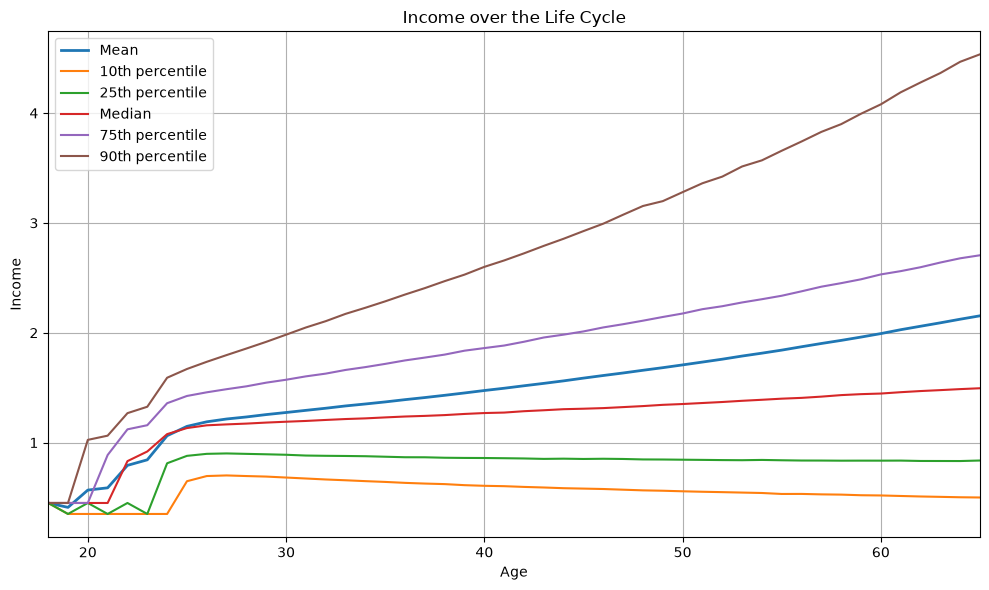

In [37]:
mean_income = np.mean(income, axis=0)

p10 = np.percentile(income, 10, axis=0)
p25 = np.percentile(income, 25, axis=0)
p50 = np.percentile(income, 50, axis=0)
p75 = np.percentile(income, 75, axis=0)
p90 = np.percentile(income, 90, axis=0)

# Plot mean income and selected percentiles

plt.figure(figsize=(10, 6))

plt.plot(ages, mean_income, label="Mean", linewidth=2)
plt.plot(ages, p10, label="10th percentile")
plt.plot(ages, p25, label="25th percentile")
plt.plot(ages, p50, label="Median")
plt.plot(ages, p75, label="75th percentile")
plt.plot(ages, p90, label="90th percentile")

plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Income over the Life Cycle")
plt.legend()
plt.grid(True)
plt.xlim(18, 65)

plt.tight_layout()
plt.show()

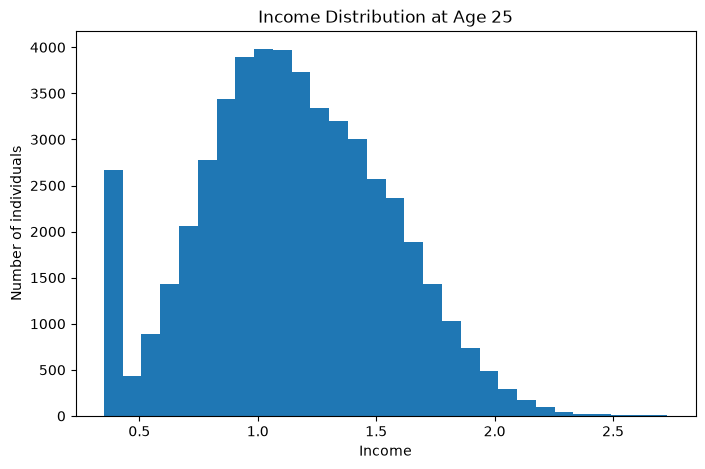

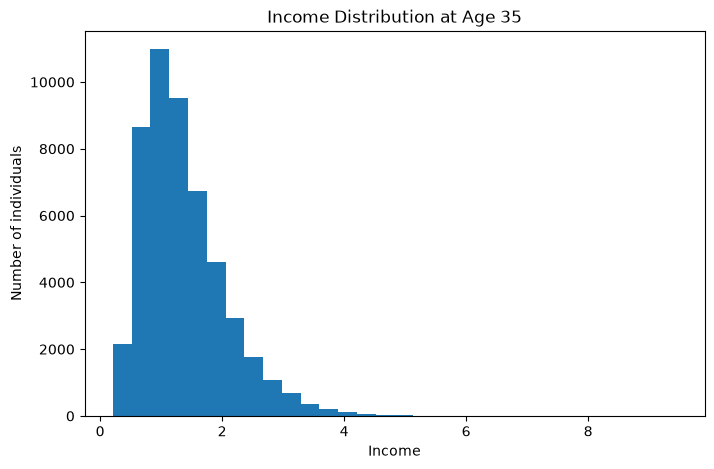

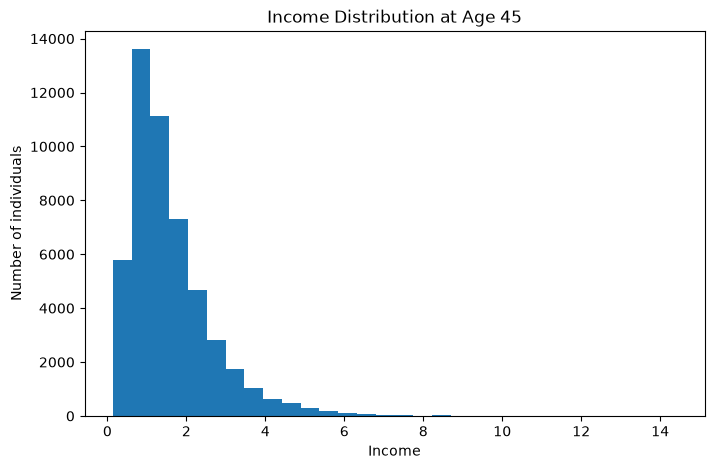

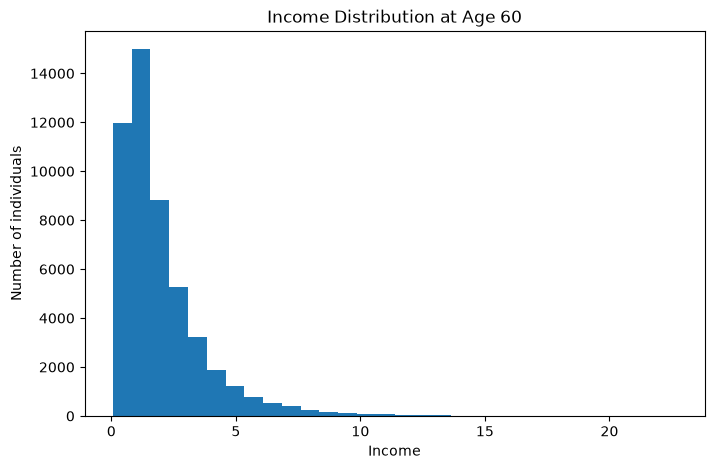

In [38]:

for age in [25, 35, 45, 60]:

    age_index = np.where(ages == age)[0][0]

    income_at_age = income[:, age_index]

    plt.figure(figsize=(8, 5))

    plt.hist(income_at_age, bins=30)

    plt.xlabel("Income")
    plt.ylabel("Number of individuals")
    plt.title(f"Income Distribution at Age {age}")

    plt.show()

## 2.3 Compute the Gini Coefficient

We compute the Gini coefficient of the simulated income distribution.
We first define our own Gini function and test it on distributions
where the theoretical answer is known.

In [39]:
def gini(x):

    # Sort incomes from lowest to highest
    x = np.sort(x)

    # Number of observations
    n = len(x)

    # Calculate the Gini coefficient
    gini_value = (2* np.sum((np.arange(1, n + 1)) * x)/ (n * np.sum(x))- (n + 1) / n)

    return gini_value

### Testing the Gini function

We test the function using a uniform distribution on [0, 1].
The theoretical Gini coefficient is 1/3.

In [40]:
# Uniform distribution

uniform_income = np.linspace(0, 1, 10000)

gini_uniform = gini(uniform_income)

print("Gini for uniform distribution:")
print(gini_uniform)

print("Theoretical Gini:")
print(1 / 3)

Gini for uniform distribution:
0.3333666666666668
Theoretical Gini:
0.3333333333333333


### Lognormal distribution

We also test the Gini function on a lognormal distribution.

In [45]:
# Lognormal distribution

s = 0.5

rng_test = np.random.default_rng(123)

lognormal_income = rng_test.lognormal(0, s, 10000)

gini_lognormal = gini(lognormal_income)

print("Gini for lognormal distribution:")
print(gini_lognormal)

Gini for lognormal distribution:
0.2741912657667991


### Gini coefficient for the full simulated sample

We calculate the Gini coefficient for all simulated income observations pooled together.

Gini coefficient for all individuals and ages pooled:
0.3772384224720413
Gini coefficient by age:
Age 18: -0.000
Age 19: 0.059
Age 20: 0.209
Age 21: 0.261
Age 22: 0.258
Age 23: 0.262
Age 24: 0.218
Age 25: 0.196
Age 26: 0.193
Age 27: 0.198
Age 28: 0.206
Age 29: 0.216
Age 30: 0.225
Age 31: 0.235
Age 32: 0.244
Age 33: 0.252
Age 34: 0.261
Age 35: 0.269
Age 36: 0.277
Age 37: 0.284
Age 38: 0.292
Age 39: 0.300
Age 40: 0.306
Age 41: 0.313
Age 42: 0.320
Age 43: 0.327
Age 44: 0.333
Age 45: 0.341
Age 46: 0.346
Age 47: 0.352
Age 48: 0.359
Age 49: 0.365
Age 50: 0.371
Age 51: 0.376
Age 52: 0.382
Age 53: 0.388
Age 54: 0.393
Age 55: 0.399
Age 56: 0.405
Age 57: 0.410
Age 58: 0.415
Age 59: 0.421
Age 60: 0.426
Age 61: 0.432
Age 62: 0.437
Age 63: 0.442
Age 64: 0.447
Age 65: 0.451


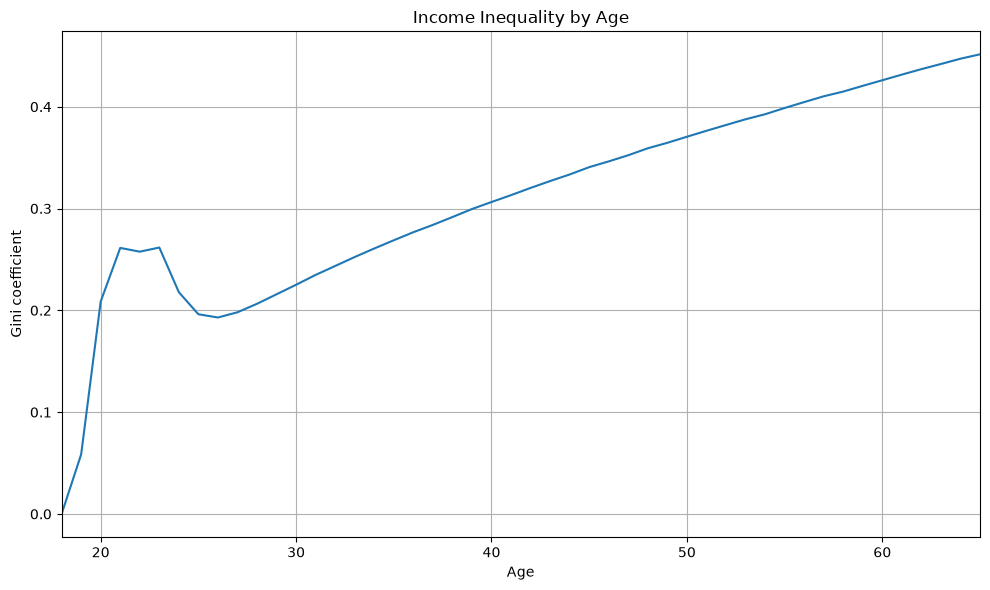

In [51]:
# Gini coefficient for all individuals and ages pooled

all_income = []

for i in range(len(income)):
    for j in range(len(ages)):
        all_income.append(income[i, j])

# Calculate the pooled Gini coefficient

gini_pooled = gini(all_income)

print("Gini coefficient for all individuals and ages pooled:")
print(gini_pooled)


# Gini coefficient by age

gini_by_age = []

for i in range(len(ages)):
    
    income_at_age = income[:, i]
    
    gini_at_age = gini(income_at_age)
    
    gini_by_age.append(gini_at_age)

print("Gini coefficient by age:")

for i in range(len(ages)):
    print(f"Age {ages[i]}: {gini_by_age[i]:.3f}")


# Plot Gini by age

plt.figure(figsize=(10, 6))

plt.plot(ages, gini_by_age)

plt.xlabel("Age")
plt.ylabel("Gini coefficient")
plt.title("Income Inequality by Age")

plt.xlim(18, 65)
plt.grid(True)

plt.tight_layout()
plt.show()

### Lorenz Curve

The Lorenz curve shows the cumulative share of total income received by the cumulative share of the population.

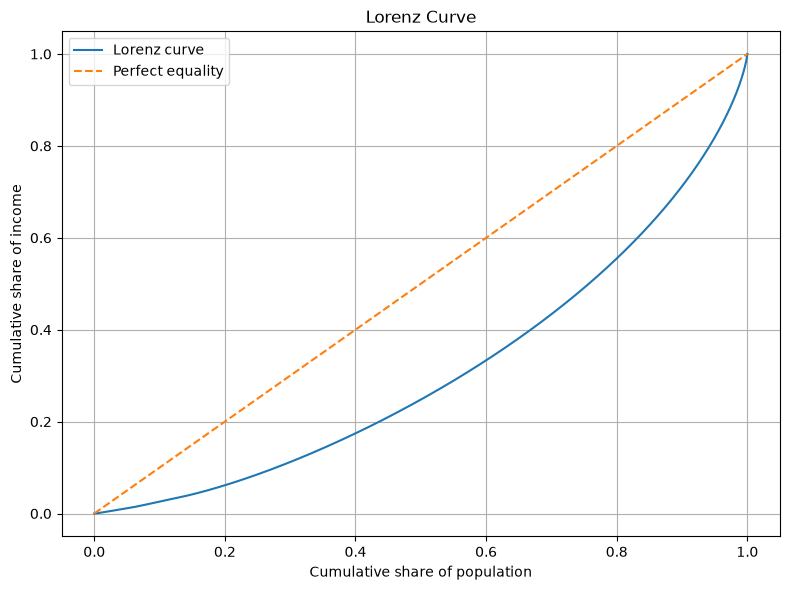

In [52]:
# Sort incomes from lowest to highest

sorted_income = sorted(all_income)

# Total income

total_income = sum(sorted_income)

# Cumulative income

cumulative_income = []

current_income = 0

for income_value in sorted_income:
    
    current_income += income_value
    
    cumulative_income.append(current_income / total_income)


# Cumulative population share

cumulative_population = []

for i in range(len(sorted_income)):
    
    cumulative_population.append((i + 1) / len(sorted_income))

plt.figure(figsize=(8, 6))

# Lorenz curve

plt.plot(cumulative_population,  cumulative_income, label="Lorenz curve")

# Line of perfect equality

plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect equality")

plt.xlabel("Cumulative share of population")
plt.ylabel("Cumulative share of income")
plt.title("Lorenz Curve")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Pooled versus within-age inequality

The pooled Gini coefficient measures inequality when individuals of all ages are considered together. It therefore captures both differences in income within age groups and differences in income across ages.

The Gini coefficients calculated separately by age measure inequality only among individuals of the same age. These coefficients show how income inequality develops over the life cycle.

The pooled Gini coefficient is higher than the inequality within most individual age groups. This indicates that differences across ages contribute to overall income inequality, in addition to differences between individuals of the same age.

In [53]:
# Compare pooled inequality with inequality within age groups

print("Pooled Gini coefficient:")
print(f"{gini_pooled:.3f}")

print("\nGini coefficient for selected ages:")

for age in [25, 35, 45, 55, 65]:

    age_index = np.where(ages == age)[0][0]

    print(f"Age {age}: {gini_by_age[age_index]:.3f}")

Pooled Gini coefficient:
0.377

Gini coefficient for selected ages:
Age 25: 0.196
Age 35: 0.269
Age 45: 0.341
Age 55: 0.399
Age 65: 0.451


## 2.4 What drives inequality?

We investigate which mechanisms in the model are important for generating income inequality.
We start by removing educational differences while keeping the other mechanisms unchanged.

In [54]:
# Reload the updated model

import importlib
importlib.reload(opgave2)


# Run the model without educational differences

education_no, ages_no, state_no, human_capital_no, income_no = opgave2.simulate_no_education()

In [56]:
# Collect all income observations

all_income_no = []

for i in range(len(income_no)):
    for j in range(len(ages_no)):
        all_income_no.append(income_no[i, j])


# Calculate pooled Gini

gini_no_education = gini(all_income_no)

print("Pooled Gini without education differences:")
print(f"{gini_no_education:.3f}")

# Gini at age 45

age = 45

age_index = np.where(ages_no == age)[0][0]

gini_no_education_45 = gini(income_no[:, age_index])

print("Gini at age 45 without education differences:")
print(f"{gini_no_education_45:.3f}")

Pooled Gini without education differences:
0.298
Gini at age 45 without education differences:
0.298
